In [2]:
import re
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import average_precision_score
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [3]:
from pathlib import Path
ROOT = Path('..')  # repo root, relative to notebooks/
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)
df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade', 'total_score', 'production_score', 'athleticism_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['made_it_contract'] = df['made_it_contract'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0) & (df['scouting_text'].str.strip() != '')].copy()
tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in tag_prefix.items():
    df[f'{col}_tagged'] = df[col].str.strip().replace('', pd.NA)
    df[f'{col}_tagged'] = df[f'{col}_tagged'].apply(lambda txt: f"{prefix}: {txt}" if pd.notna(txt) else '')

df['scouting_text_tagged'] = (
    df[[f'{col}_tagged' for col in text_cols]]
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


In [4]:
# â”€â”€ NFL stopword config (from nfl_pre_proc.ipynb) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Directional adjectives NLTK would stop that carry real scouting meaning
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide', 'pass',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
# Generic scouting filler: appears in nearly every report, zero discriminative signal
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
# Outcome-leaking phrases stripped before any processing
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

print(f'NFL stop list: {len(NFL_STOPWORDS)} words '
      f'({len(KEEP_WORDS & _base_stops)} directionals un-stopped, {len(CUSTOM_STOPS)} filler added)')


def nfl_preprocess_no_stitch(text: str) -> str:
    """NFL-aware preprocessing without compound phrase stitching.

    Steps: lowercase â†’ strip outcome-leaking phrases â†’ normalize hyphens â†’
    alpha-only â†’ tokenize â†’ NFL stopwords â†’ lemmatize.
    TF-IDF bigrams (ngram_range=(1,2)) capture collocations like 'pass rush'
    naturally without needing to stitch them into 'pass_rush' tokens.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)   # normalize hyphens â†’ space
    text = re.sub(r'[^a-z\s]', ' ', text)           # letters and spaces only
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Apply preprocessing to each field independently, then rebuild scouting_text_tagged
_tag_prefix = {'overview': 'OVR', 'strengths': 'STR', 'weaknesses': 'WKN'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

def _build_tagged_clean(row):
    parts = [f"{prefix}: {row[f'{col}_clean']}"
             for col, prefix in _tag_prefix.items()
             if str(row[f'{col}_clean']).strip()]
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(_build_tagged_clean, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

# Quick sanity checks
token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players after preprocessing: {len(df)}')
print(f'Tokens/player â€” median: {int(token_counts.median())}, '
      f'mean: {token_counts.mean():.0f}, '
      f'min: {token_counts.min()}, max: {token_counts.max()}')
print()
# Verify key directionals kept, filler removed
sample = df['scouting_text_tagged'].iloc[0]
print('Sample (first 300 chars):')
print(sample[:300])

NFL stop list: 225 words (8 directionals un-stopped, 35 filler added)
Players after preprocessing: 5321
Tokens/player â€” median: 133, mean: 135, min: 30, max: 392

Sample (first 300 chars):
OVR: physical specimen rare size speed combination clowney impactful junior playing through injury forced deal opposing offense fully accounted extra chip protection old junior affected turnover defensive coaching staff could benefit tremendously stable positional coach strong veteran mentor defensi


In [5]:
# Updated params: lower max_features + min_df floor to remove hapax bigrams,
# sublinear_tf=True since docs are ~150-200 tokens (TF is nearly binary at this length).
# stop_words removed â€” handled upstream by nfl_preprocess_no_stitch.
vectorizer_params = dict(max_features=1000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)

numeric_features = ['grade', 'total_score', 'production_score', 'athleticism_score']
cat_features = ['Pos_Group']

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]

class YearNormalizedTfidf(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='scouting_text', year_column='year', vectorizer_params=None):
        self.text_column = text_column
        self.year_column = year_column
        self.vectorizer_params = vectorizer_params or {}
        self.vectorizer = TfidfVectorizer(**self.vectorizer_params)

    def fit(self, X, y=None):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.fit_transform(texts)
        arr = tfidf.toarray()
        self.year_means_ = {}
        for year in np.unique(years):
            mask = years == year
            if mask.sum():
                self.year_means_[year] = arr[mask].mean(axis=0)
        self.global_mean_ = arr.mean(axis=0)
        return self

    def transform(self, X):
        texts = X[self.text_column].fillna('')
        years = X[self.year_column].astype(int).values
        tfidf = self.vectorizer.transform(texts)
        arr = tfidf.toarray()
        adjusted = arr.copy()
        for year, mean in self.year_means_.items():
            mask = years == year
            if mask.sum():
                adjusted[mask] -= mean
        unseen_mask = ~np.isin(years, list(self.year_means_.keys()))
        if unseen_mask.any():
            adjusted[unseen_mask] -= self.global_mean_
        return adjusted

text_pipeline = Pipeline([
    ('selector', ColumnSelector(['scouting_text_tagged', 'year'])),
    ('year_norm', YearNormalizedTfidf(text_column='scouting_text_tagged', vectorizer_params=vectorizer_params)),
])

meta_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop',
)

preprocessor = FeatureUnion([
    ('text', text_pipeline),
    ('meta', meta_transformer),
])

pipe = Pipeline([
    ('features', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
])

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('grade', StandardScaler(), ['grade']),
        ('pos', OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
    ],
    remainder='drop',
)
baseline_pipe = Pipeline([
    ('preproc', baseline_preprocessor),
    ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
])

train_mask = df.year.between(2014, 2021) & df.made_it_contract.notna()
train_df = df.loc[train_mask].copy()
train_df['made_it_contract'] = train_df['made_it_contract'].astype(int)
y_train = train_df['made_it_contract']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

positive_rate = y_train.mean()
desired_rate = 0.3
if positive_rate in (0, 1):
    pos_weight = neg_weight = 1.0
else:
    pos_weight = desired_rate / positive_rate
    neg_weight = (1 - desired_rate) / (1 - positive_rate)
baseline_weights = y_train * pos_weight + (1 - y_train) * neg_weight

text_scores = cross_val_score(pipe, train_df, y_train, cv=cv, scoring='average_precision')
baseline_scores = []
for train_idx, test_idx in cv.split(train_df, y_train):
    estimator = clone(baseline_pipe)
    estimator.fit(train_df.iloc[train_idx], y_train.iloc[train_idx], lr__sample_weight=baseline_weights.iloc[train_idx])
    preds = estimator.predict_proba(train_df.iloc[test_idx])[:, 1]
    baseline_scores.append(average_precision_score(y_train.iloc[test_idx], preds))
baseline_scores = np.array(baseline_scores)

print("Text + scores + pos PR-AUC: %.3f +- %.3f" % (text_scores.mean(), text_scores.std()))
print("Calibrated grade + Pos_Group PR-AUC: %.3f +- %.3f" % (baseline_scores.mean(), baseline_scores.std()))


Text + scores + pos PR-AUC: 0.560 +- 0.029
Calibrated grade + Pos_Group PR-AUC: 0.556 +- 0.031


In [6]:
# Compare plain TF-IDF vs year-normalized TF-IDF
# Year normalization subtracts per-draft-class mean vectors — tests whether
# language drift across years is real enough to matter with only 8 training years.
from sklearn.preprocessing import FunctionTransformer

plain_text_pipeline = Pipeline([
    ('selector', ColumnSelector(['scouting_text_tagged'])),
    ('squeeze', FunctionTransformer(lambda x: x.squeeze())),
    ('tfidf', TfidfVectorizer(**vectorizer_params)),
])
plain_pipe = Pipeline([
    ('features', FeatureUnion([
        ('text', plain_text_pipeline),
        ('meta', meta_transformer),
    ])),
    ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42, n_jobs=-1)),
])

plain_scores = cross_val_score(plain_pipe, train_df, y_train, cv=cv, scoring='average_precision')

print("Plain TF-IDF PR-AUC:           %.3f +- %.3f" % (plain_scores.mean(), plain_scores.std()))
print("Year-normalized TF-IDF PR-AUC: %.3f +- %.3f" % (text_scores.mean(), text_scores.std()))
print("Baseline (grade + pos) PR-AUC: %.3f +- %.3f" % (baseline_scores.mean(), baseline_scores.std()))


Plain TF-IDF PR-AUC:           0.554 +- 0.030
Year-normalized TF-IDF PR-AUC: 0.560 +- 0.029
Baseline (grade + pos) PR-AUC: 0.556 +- 0.031


In [7]:
pipe.fit(train_df, y_train)
baseline_pipe.fit(train_df, y_train, lr__sample_weight=baseline_weights)

future_df = df[df.year.between(2022, 2025)].copy()
future_df['pred_made_it'] = pipe.predict_proba(future_df)[:, 1]
future_df['baseline_score'] = baseline_pipe.predict_proba(future_df)[:, 1]
cols = ['year', 'player_name', 'team', 'Pos_Group', 'grade', 'total_score', 'pred_made_it', 'baseline_score']
future_summary = future_df.sort_values(['pred_made_it'], ascending=False)[cols].head(12)
future_summary


,year,player_name,team,Pos_Group,grade,total_score,pred_made_it,baseline_score
5396,2022,Evan Neal,New York Giants,OL,6.76,86.0,0.7475,0.754250
5412,2022,Malik Willis,Tennessee Titans,QB,6.41,80.0,0.7425,0.528205
6355,2024,JC Latham,Tennessee Titans,OL,6.71,87.0,0.7250,0.734969
6843,2025,Cam Ward,Tennessee Titans,QB,6.39,86.0,0.7150,0.518085
5418,2022,Kenny Pickett,Pittsburgh Steelers,QB,6.40,84.0,0.7125,0.523148
5863,2023,Bryce Young,Carolina Panthers,QB,6.82,90.0,0.6925,0.720030
6367,2024,Olumuyiwa Fashanu,New York Jets,OL,6.45,87.0,0.6750,0.620715
6819,2025,Travis Hunter,Jacksonville Jaguars,WR,6.89,92.0,0.6725,0.672101
5399,2022,Kayvon Thibodeaux,New York Giants,EDGE,6.72,86.0,0.6675,0.703148
6359,2024,Joe Alt,Los Angeles Chargers,OL,6.49,97.0,0.6650,0.639621


C:\Users\sffra\AppData\Local\Temp\ipykernel_4820\498317992.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


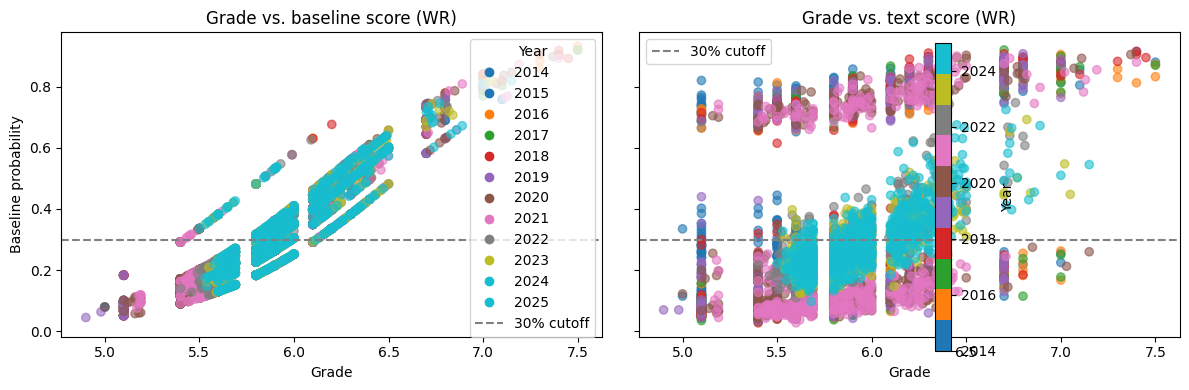

In [8]:
import matplotlib.pyplot as plt

wr = df.copy()
wr = wr[wr['grade'] > 0]
wr['text_score'] = pipe.predict_proba(wr)[:, 1]
wr['baseline_score'] = baseline_pipe.predict_proba(wr)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

from matplotlib import lines

norm = plt.Normalize(wr['year'].min(), wr['year'].max())
cmap = plt.colormaps['tab10']
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

for ax, score, title in zip(
    axes,
    ['baseline_score', 'text_score'],
    ['Grade vs. baseline score (WR)', 'Grade vs. text score (WR)']
):
    ax.scatter(
        wr['grade'],
        wr[score],
        c=wr['year'],
        cmap=cmap,
        norm=norm,
        alpha=0.6
    )
    ax.set_title(title)
    ax.set_xlabel('Grade')
    if score == 'baseline_score':
        ax.set_ylabel('Baseline probability')
    ax.axhline(0.3, color='gray', ls='--')

year_handles = [
    lines.Line2D([0], [0], marker='o', linestyle='', color=cmap(norm(year)), label=str(year))
    for year in sorted(wr['year'].unique())
]
cutoff_handle = lines.Line2D([0], [0], color='gray', ls='--', label='30% cutoff')
axes[0].legend(handles=year_handles + [cutoff_handle], title='Year')
axes[1].legend(handles=[cutoff_handle])

fig.colorbar(sm, ax=axes.ravel().tolist(), label='Year')
plt.tight_layout()


C:\Users\sffra\AppData\Local\Temp\ipykernel_4820\3277481058.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


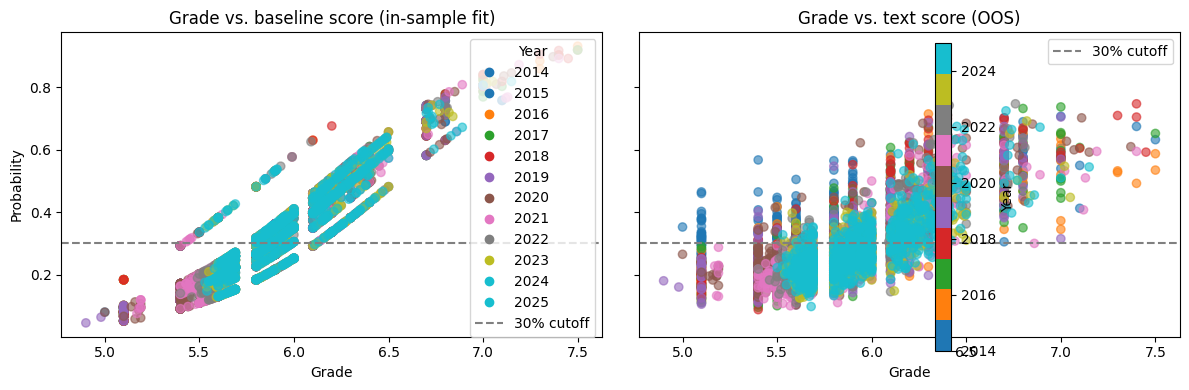

In [9]:
# Out-of-sample scatter
# Text model: OOF for 2014-2021, fully held-out for 2022-2025
# Baseline: fully-fitted model used for scatter only (LR does not meaningfully overfit;
#           OOF baseline is used for PR-AUC above, not here)
from sklearn.model_selection import cross_val_predict

# OOF text probabilities for labeled years
oof_text = cross_val_predict(pipe, train_df, y_train, cv=cv, method='predict_proba')[:, 1]

scatter_train = train_df.copy()
scatter_train['text_score'] = oof_text
scatter_train['baseline_score'] = baseline_pipe.predict_proba(train_df)[:, 1]

scatter_future = future_df.copy()
scatter_future['text_score'] = scatter_future['pred_made_it']

scatter_df = pd.concat([scatter_train, scatter_future], ignore_index=True)
scatter_df = scatter_df[scatter_df['grade'] > 0]

import matplotlib.pyplot as plt
from matplotlib import lines

norm = plt.Normalize(scatter_df['year'].min(), scatter_df['year'].max())
cmap = plt.colormaps['tab10']
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, score, title in zip(
    axes,
    ['baseline_score', 'text_score'],
    ['Grade vs. baseline score (in-sample fit)', 'Grade vs. text score (OOS)']
):
    ax.scatter(
        scatter_df['grade'],
        scatter_df[score],
        c=scatter_df['year'],
        cmap=cmap,
        norm=norm,
        alpha=0.6,
    )
    ax.set_title(title)
    ax.set_xlabel('Grade')
    if score == 'baseline_score':
        ax.set_ylabel('Probability')
    ax.axhline(0.3, color='gray', ls='--')

year_handles = [
    lines.Line2D([0], [0], marker='o', linestyle='', color=cmap(norm(y)), label=str(y))
    for y in sorted(scatter_df['year'].unique())
]
cutoff_handle = lines.Line2D([0], [0], color='gray', ls='--', label='30% cutoff')
axes[0].legend(handles=year_handles + [cutoff_handle], title='Year')
axes[1].legend(handles=[cutoff_handle])

fig.colorbar(sm, ax=axes.ravel().tolist(), label='Year')
plt.tight_layout()
